In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as f
import seaborn as sns
from pyspark.sql.types import *
import matplotlib.pyplot as plt

Matplotlib created a temporary cache directory at /tmp/matplotlib-efxjnetz because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Initialisation - Version configuration sans allocation de mémoire

#### Remarque: c'est trop lent

## Initialisation - Version configuration de la mémoire allouée

In [2]:
spark = (
    SparkSession.builder
    .appName("ReadCSV-optimized")
    .master("spark://spark-master:7077")
    # Executors (<= ressources des workers)
    .config("spark.executor.instances", "3")   # 3 exécuteurs
    .config("spark.executor.cores", "2")       # 2 cœurs / exécuteur  => 6 cœurs au total
    .config("spark.executor.memory", "4g")     # 4 Go / exécuteur     => ~12 Go au total
    # Driver (le notebook)
    .config("spark.driver.memory", "2g")
    # Shuffle & lecture de fichiers (plus raisonnable que 200)
    .config("spark.sql.shuffle.partitions", "48")
    .config("spark.sql.files.maxPartitionBytes", str(64*1024*1024))  # 64 MiB
    .getOrCreate()
)

print("Spark:", spark.version)

Spark: 3.5.0


## Chargement des données, inspection et correction des erreurs de chargement.

**Question** Créez un Dataframe à partir du fichier /data/data_prime_auto.csv en positionnant l'option "inferSchema" à True

In [3]:
path = "/data/data_prime_auto.csv"  # le chemin accessible au cluster
data = spark.read\
            .option("inferSchema",True)\
            .option("header",True)\
            .csv(path)

**Question** Affichez les 10 premières lignes du DataFrame

In [4]:
data.show(10)

+---+---------------+------------+--------+------------+-------+----------+---------------+------------+---+----+-------------+
| id|annee_naissance|annee_permis|  marque|puis_fiscale|anc_veh|codepostal|    energie_veh|kmage_annuel|crm|var1|prime_tot_ttc|
+---+---------------+------------+--------+------------+-------+----------+---------------+------------+---+----+-------------+
|  1|         1986.0|        2006| RENAULT|           4|      1|      1034|            gpl|        2924| 68|  10|       254.75|
|  2|         1986.0|        2006| RENAULT|           8|      2|      1034|            gpl|       11580| 50|  10|       259.89|
|  3|         1982.0|        2001| RENAULT|           7|      2|      1034|            gpl|        7149| 95|  15|       431.65|
|  4|         1987.0|        2006|   DACIA|           5|      2|      1034|            gpl|        6526|100|  10|       577.99|
|  5|         1994.0|        2013| CITROEN|           4|      2|      1034|            gpl|        2872|

**Question** Vérifiez que le DataFrame est de dimension (300006,12)

In [5]:
n_cols = len(data.columns)
n_rows = data.count()
print("DataFrame shape=(%i,%i)"%(n_rows,n_cols))

DataFrame shape=(300006,12)


**Question** Appelez la méthode describe pour afficher les statistiques. Interprétez les résultats et identifiez les anomalies potentielles

In [6]:
data.describe().show(10,20)

+-------+------------------+-----------------+------------------+------+------------------+------------------+------------------+---------------+------------------+------------------+------------------+------------------+
|summary|                id|  annee_naissance|      annee_permis|marque|      puis_fiscale|           anc_veh|        codepostal|    energie_veh|      kmage_annuel|               crm|              var1|     prime_tot_ttc|
+-------+------------------+-----------------+------------------+------+------------------+------------------+------------------+---------------+------------------+------------------+------------------+------------------+
|  count|            300006|           299714|            299714|300004|            300004|            300004|            300004|         300004|            300004|            300004|            299714|            300004|
|   mean|149997.51498303367| 1983.68277424478|2003.0514724036916|  NULL|6.8252889961467185|  16.3627518299756| 4

**Réponse** 
- Toutes les colonnes ont un nombre de lignes < 300006, ce qui indique la présence de valeurs nulles. 
- codepostal, energie_veh ont des valuers à NR ou "Non Renseigné" => signe de données manquantes.
- prime_tot_ttc contient au moins une valeur négative
- puis_fiscale fiscale à au moins une valeur à 0
- annee_naissance et annee_permis ont des dates dans le futur
- anc_veh à au moins une valeur à 99, peut être voiture de collection ou anomalie
- crm a une valeur max de 270. Peut être une anomalie

**Question** Appelez printSchema. Identifiez les anomalies de types.

In [7]:
data.printSchema()

root
 |-- id: integer (nullable = true)
 |-- annee_naissance: double (nullable = true)
 |-- annee_permis: integer (nullable = true)
 |-- marque: string (nullable = true)
 |-- puis_fiscale: integer (nullable = true)
 |-- anc_veh: integer (nullable = true)
 |-- codepostal: string (nullable = true)
 |-- energie_veh: string (nullable = true)
 |-- kmage_annuel: integer (nullable = true)
 |-- crm: integer (nullable = true)
 |-- var1: integer (nullable = true)
 |-- prime_tot_ttc: double (nullable = true)



**Réponse** 
- La colonne annee_naissance est détectée comme double, alors qu'elle doit être integer.
- La colonne codepostal est détectée comme string alors que ca devrait être une valeur numérique. Ce n'est pas une anomalie en soit, mais il se trouve que des valeurs non numériques=> Ne correspondant pas à un vrai code postal sont présentes.

In [8]:
data.schema

StructType([StructField('id', IntegerType(), True), StructField('annee_naissance', DoubleType(), True), StructField('annee_permis', IntegerType(), True), StructField('marque', StringType(), True), StructField('puis_fiscale', IntegerType(), True), StructField('anc_veh', IntegerType(), True), StructField('codepostal', StringType(), True), StructField('energie_veh', StringType(), True), StructField('kmage_annuel', IntegerType(), True), StructField('crm', IntegerType(), True), StructField('var1', IntegerType(), True), StructField('prime_tot_ttc', DoubleType(), True)])

**Note** Le schéma affiché ci-dessus est copié-collé ci-dessous. Les types des colonnes annee_naissance est code_postal sont corrigés.

In [9]:
prime_auto_schema = StructType([StructField('id', IntegerType(), True), 
            StructField('annee_naissance', IntegerType(), True),
            StructField('annee_permis', IntegerType(), True),
            StructField('marque', StringType(), True), 
            StructField('puis_fiscale', IntegerType(), True), 
            StructField('anc_veh', IntegerType(), True), 
            StructField('codepostal', IntegerType(), True), 
            StructField('energie_veh', StringType(), True), 
            StructField('kmage_annuel', IntegerType(), True), 
            StructField('crm', IntegerType(), True), 
            StructField('var1', IntegerType(), True), 
            StructField('prime_tot_ttc', DoubleType(), True)])

In [10]:
path = "/data/data_prime_auto.csv"  # le chemin accessible au cluster
data = spark.read\
            .option("header",True)\
            .schema(prime_auto_schema) \
            .csv(path)

In [11]:
data.printSchema()

root
 |-- id: integer (nullable = true)
 |-- annee_naissance: integer (nullable = true)
 |-- annee_permis: integer (nullable = true)
 |-- marque: string (nullable = true)
 |-- puis_fiscale: integer (nullable = true)
 |-- anc_veh: integer (nullable = true)
 |-- codepostal: integer (nullable = true)
 |-- energie_veh: string (nullable = true)
 |-- kmage_annuel: integer (nullable = true)
 |-- crm: integer (nullable = true)
 |-- var1: integer (nullable = true)
 |-- prime_tot_ttc: double (nullable = true)



**Note** Corrections des types constatées.

In [12]:
data.describe().show(10,20)

+-------+------------------+-----------------+------------------+------+------------------+------------------+------------------+---------------+------------------+------------------+------------------+------------------+
|summary|                id|  annee_naissance|      annee_permis|marque|      puis_fiscale|           anc_veh|        codepostal|    energie_veh|      kmage_annuel|               crm|              var1|     prime_tot_ttc|
+-------+------------------+-----------------+------------------+------+------------------+------------------+------------------+---------------+------------------+------------------+------------------+------------------+
|  count|            300006|           299712|            299714|300004|            300004|            300004|            299996|         300004|            300004|            300004|            299714|            300004|
|   mean|149997.51498303367|1983.682768791373|2003.0514724036916|  NULL|6.8252889961467185|  16.3627518299756| 4

**Réponse** Les colonnes annee_naissance et codepostal contiennent moins de valeurs => Présence de valeurs à null, données non numériques sont nulles maintenant.

In [13]:
data.columns

['id',
 'annee_naissance',
 'annee_permis',
 'marque',
 'puis_fiscale',
 'anc_veh',
 'codepostal',
 'energie_veh',
 'kmage_annuel',
 'crm',
 'var1',
 'prime_tot_ttc']

- 'id': identifiant doit être unique non null
- 'annee_naissance': Numérique, non null, >0, <=année en cours-16, <=annee_permis - 16, 
- 'annee_permis': Numérique, non null, >0, <=année en cours, >=année_naissance + 16
- 'marque': Variable catégorielle, Non nulle. Doit être validée avec un dictionnaire.
- 'puis_fiscale': Valeur numérique non nulle comprise entre 4 et 100
- 'anc_veh': Valeur numérique non nulle >=0
- 'codepostal': Variable catégorielle, non nulle. doit être validée avec un dictionnaire.
- 'energie_veh': Varaible catégorielle, non nulle, doit être validée avec un dictionnaire
- 'kmage_annuel': Variable numérique non nulle >0.
- 'crm': Variable numérique non nulle >50 et
- 'var1': Variable numérique, non identifiéer.
- 'prime_tot_ttc: Variable numérique, non nulle, >0, une analyse des données extrêmes doit être effectuée pour déterminer s'il s'agit d'anomalies.

Pour toutes les données il faut rechercher les données rares et déterminer s'il s'agit d'anomalies.

**Question** Vérifiez que toutes les valeurs de la colonne ID sont uniques. S'agit-il de lignes dupliquées ? S'il existe des lignes dupliquées, supprimez-les

In [14]:
n_rows = data.count()
non_unique_id_count =  n_rows - data.select(["id"]).distinct().count()
print("le nombre de lignes avec des id dupliqués sont ", non_unique_id_count)

le nombre de lignes avec des id dupliqués sont  6


In [15]:
n_rows = data.count()
data = data.drop_duplicates()
#Vérification
print("le nombre de lignes dupliquées sont ", n_rows-data.distinct().count())

le nombre de lignes dupliquées sont  6


**Question** Comptez, puis supprimez les lignes vides si vous en trouvez (attention au piège)

In [16]:
n_rows = data.count()
data=data.dropna(how="all", subset=data.columns[1:])
n_rows_tmp = data.count()
print("le nombre de lignes nulles est", n_rows - n_rows_tmp)
n_rows = n_rows_tmp

le nombre de lignes nulles est 2


**Réponse** Une ligne vide peut avoir un id non null. La denirère transformation élimine les lignes vides. Noter le "slice" de la colonne id.

## Recherche d'anomalies: variables numériques

**Question** Le responsable du sondage vous explique qu'un problème informatique a fait perdre certaines informations dans la base, comme les années de naissance et les année de permis. Comptez ces anomalies et affichez quelques lignes correspondantes à ces critères.

In [17]:
null_an_ap = data.filter(f.isnull("annee_permis") & f.isnull("annee_naissance")).count()
print("le nombre de lignes correspondant à ces critères est", null_an_ap)
data.filter(f.isnull("annee_permis") & f.isnull("annee_naissance")).show(10)

le nombre de lignes correspondant à ces critères est 290
+------+---------------+------------+------+------------+-------+----------+-----------+------------+---+----+-------------+
|    id|annee_naissance|annee_permis|marque|puis_fiscale|anc_veh|codepostal|energie_veh|kmage_annuel|crm|var1|prime_tot_ttc|
+------+---------------+------------+------+------------+-------+----------+-----------+------------+---+----+-------------+
|162876|           NULL|        NULL|    NR|           0|      1|     54600|         NR|       17000| 50|NULL|       182.84|
|171757|           NULL|        NULL|    NR|           0|      0|     59058|         NR|       17000| 50|NULL|       188.32|
|203286|           NULL|        NULL|    NR|           0|      7|     69081|         NR|       17000| 50|NULL|       196.91|
|144750|           NULL|        NULL|    NR|           0|     37|     45232|         NR|       17000| 50|NULL|       202.57|
|198462|           NULL|        NULL|    NR|           0|      4|   

**Question** 2.	Vous décidez de supprimez ces lignes. Est-ce un bon choix ?

**Réponse** Les nombre de lignes étant très faible par rapport aux nombre total, les supprimer ne sera pas très impactant en vue des analyses prévues.

**Question** Supprimez les lignes et faites un describe. Que constatez-vous ?

In [18]:
n_rows_avant = data.count()
data = data.filter(f.isnotnull("annee_permis") | f.isnotnull("annee_naissance"))
n_rows = data.count()
n_rows_supprime = n_rows - n_rows_avant
print("Nombre de lignes suppimées : ",n_rows_supprime)

Nombre de lignes suppimées :  -290


**Question** Surpprimez toutes les lignes qui contiennent au moins une valeur null. Vérifiez avec describe.

In [19]:
data = data.dropna()
n_rows = data.count()
data.describe().show()

+-------+------------------+-----------------+------------------+------+-----------------+-----------------+-----------------+---------------+------------------+-----------------+------------------+------------------+
|summary|                id|  annee_naissance|      annee_permis|marque|     puis_fiscale|          anc_veh|       codepostal|    energie_veh|      kmage_annuel|              crm|              var1|     prime_tot_ttc|
+-------+------------------+-----------------+------------------+------+-----------------+-----------------+-----------------+---------------+------------------+-----------------+------------------+------------------+
|  count|            299698|           299698|            299698|299698|           299698|           299698|           299698|         299698|            299698|           299698|            299698|            299698|
|   mean|149994.28349872204|1983.683034254483|2003.0517287402652|  NULL|6.831884096657301|16.36650227896082|49702.71976789969|  

- **Question** Utilisez la fonction histplot de du package seaborn pour afficher les histogrammes de toutes les variables numériques
- **Question** Utilisez la fonction boxplot de seaborn avec les mêmes données que la question précédente

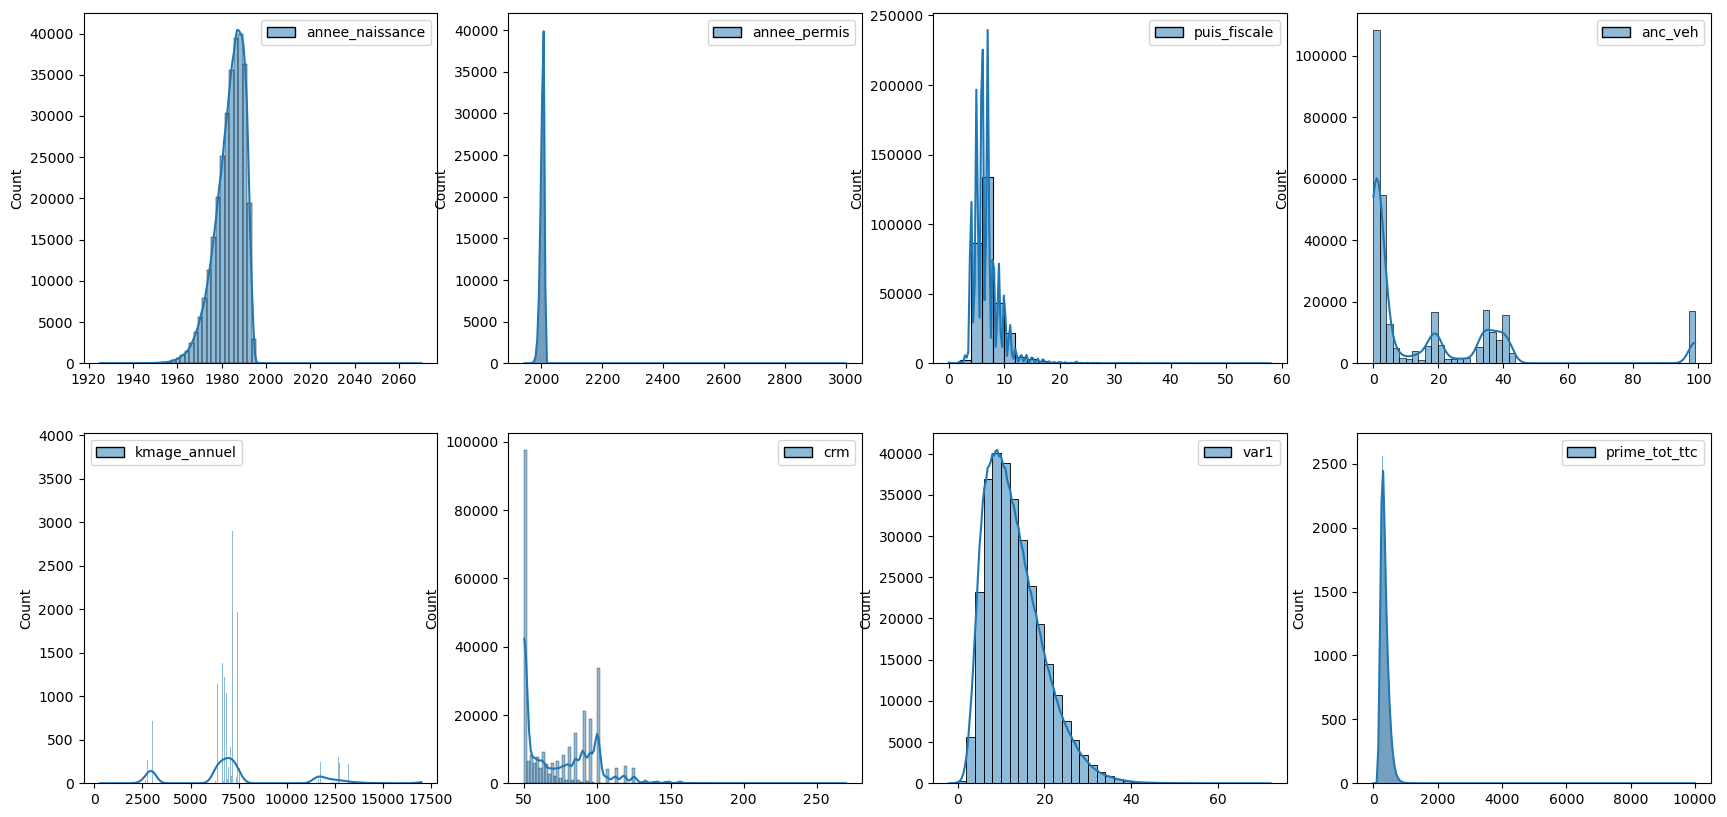

<Figure size 640x480 with 0 Axes>

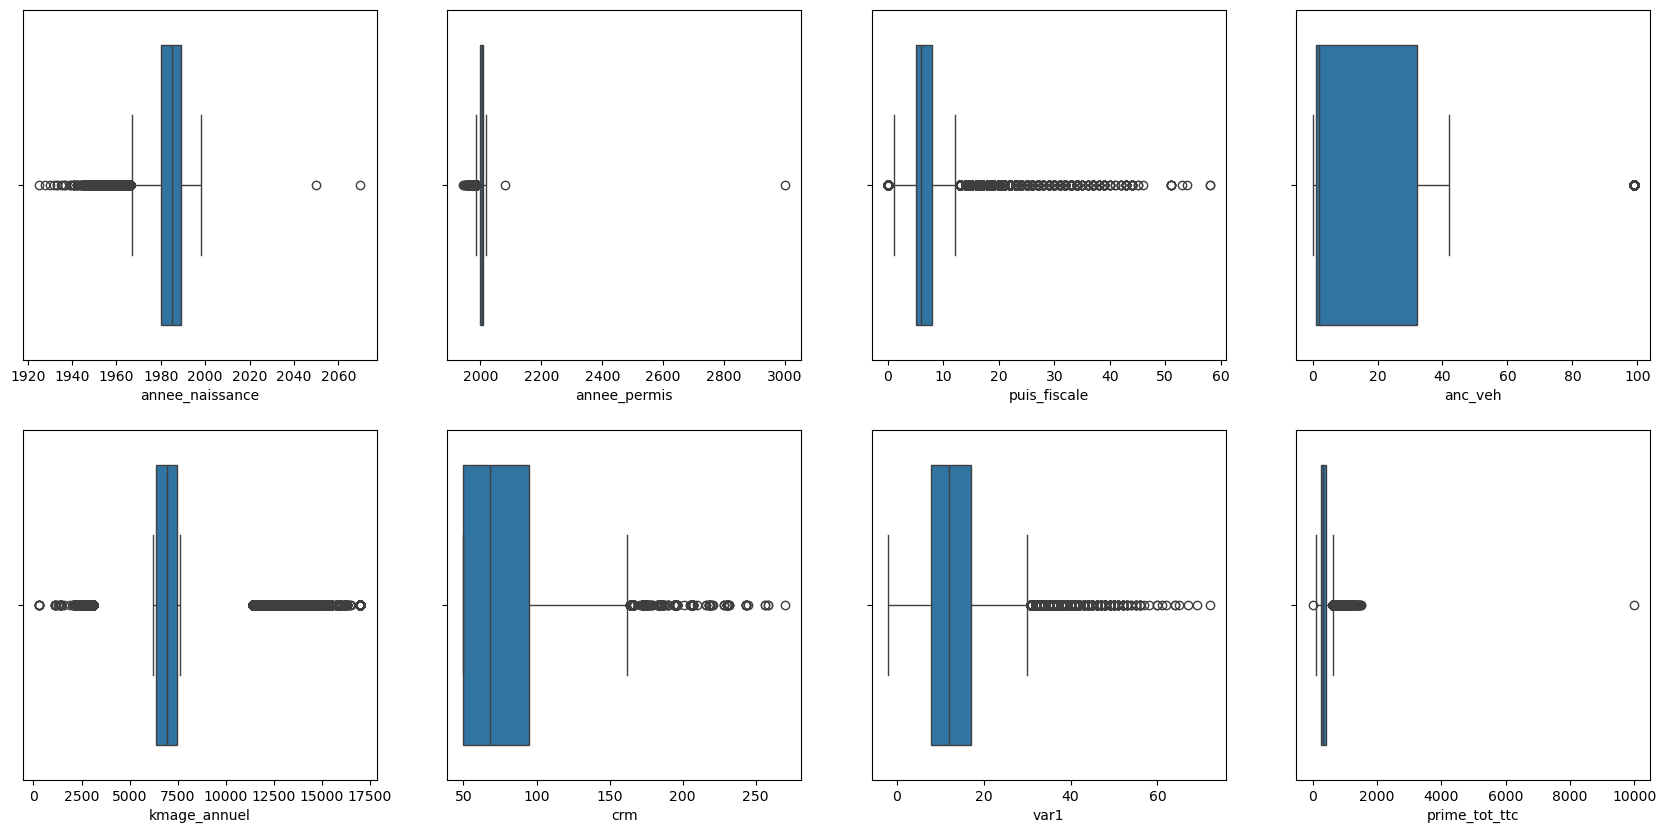

In [20]:
num_vars_cols = ['annee_naissance','annee_permis','puis_fiscale','anc_veh','kmage_annuel','crm','var1','prime_tot_ttc']
fig, axs = plt.subplots(2, 4, figsize=(21, 10))
subs = {'annee_naissance':axs[0,0],'annee_permis':axs[0,1],'puis_fiscale':axs[0,2],'anc_veh':axs[0,3],'kmage_annuel':axs[1,0],'crm':axs[1,1],'var1':axs[1,2],'prime_tot_ttc':axs[1,3]}
for c_name in num_vars_cols:
    sns.histplot(data.select(c_name).toPandas(),kde=True,binwidth=2,ax=subs[c_name])
plt.show()
plt.figure()
fig, axs = plt.subplots(2, 4, figsize=(21, 10))
subs = {'annee_naissance':axs[0,0],'annee_permis':axs[0,1],'puis_fiscale':axs[0,2],'anc_veh':axs[0,3],'kmage_annuel':axs[1,0],'crm':axs[1,1],'var1':axs[1,2],'prime_tot_ttc':axs[1,3]}
for c_name in num_vars_cols:
    sns.boxplot(x=data.select(c_name).toPandas()[c_name],ax=subs[c_name])
plt.show()

**Réponse** Commentez les graphs

- annee_naissance: Potentiel valeurs aberrantes ou de faibles quantité. La distribution n'est pas symétrique
- anne_permis: La distribution est différentes que celle de année de naissance. avec potentiels valeurs faible quantité. La distribution n'est pas symétrique
- puis_fiscale: valeurs autour de 8, avec potentiels données extrème. Puissance fiscale semble être une catégorie.
- anc_veh: données constituées surtout de véhicules entre 0 et 10 ans. 4 groupes probables.
- kmage_annuel: Discontinuité dans les valeurs. 4 groupes probables.
- crm: distribution quasi uniforme avec des exceptions plus de valeurs à 50
- var1: Distribution non symétrique
- prim_tot_ttc: potentielles anomalies avec une distribution presque symétrique.

**Question** Identifiez les anomalies résiduelles des colonnes annee_naissance et annee_permis et supprimez/corrigez les.

In [21]:
#Le sondage a été effectué en 2016. Toute date de annee_permis au dessus de cette date est une anomalie
ap_sup_2018 = (f.col("annee_permis") > 2016)
#Anee de permis ne dois pas être inférieure à annee_naissance+16
ap_rel_an = (f.col("annee_permis")<(f.col("annee_naissance")+16))
#annee_naissance ne doit pas être nulle
an_no_null = f.isnotnull(f.col("annee_naissance"))
n_rows = data.count()
#filtrer d'abord les annee_naissance à null. C'est un peu risqué car on ne sait pas dans quel ordre Spark effectue les opération
data = data.filter(an_no_null)
data = data.filter(~(ap_sup_2018 | ap_rel_an))
""" Ce filtre doit aussi supprimer les fois ou annee_naissance est >
annee_permis. Une autre option sera de corriger annee_naissance avant ce 
filtre en supposant que annee_naissance = annee permis-16, ce qui n'est pas tout le 
temps vrai, mais permet de supprimer moins d'observations sans risque de perturber les analyses"""
n_rows_tmp = data.count()
print("nombre de lignes filtrées = ",n_rows-n_rows_tmp) 
n_rows = n_rows_tmp

nombre de lignes filtrées =  10


**Question** Identifiez les anomalies dans la colonne prime_tot_ttc

In [22]:
Q1,Q2,Q3 = data.select(f.percentile(f.col("prime_tot_ttc"), [0.25,0.5,0.75], f.lit(1))).collect()[0][0]
IQR  = Q3 - Q1
f1 = f.col("prime_tot_ttc") < (Q1 - 1.5 * IQR)
f2 = f.col("prime_tot_ttc") > ( Q3 + 1.5 * IQR)
print("Nombre d'anomalies détectées type (Q1 - 1.5 * IQR)",data.filter(f1).count())
data.filter(f1).show()
print("Nombre d'anomalies détectées type (Q3 + 1.5 * IQR)",data.filter(f2).count())
data.filter(f2).sort(f.col("prime_tot_ttc"),ascending=False).show()

Nombre d'anomalies détectées type (Q1 - 1.5 * IQR) 1
+---+---------------+------------+--------+------------+-------+----------+-----------+------------+---+----+-------------+
| id|annee_naissance|annee_permis|  marque|puis_fiscale|anc_veh|codepostal|energie_veh|kmage_annuel|crm|var1|prime_tot_ttc|
+---+---------------+------------+--------+------------+-------+----------+-----------+------------+---+----+-------------+
|199|           1982|        2001|CHRYSLER|           7|      2|      1034|     gazole|       12441|100|  15|         -1.0|
+---+---------------+------------+--------+------------+-------+----------+-----------+------------+---+----+-------------+

Nombre d'anomalies détectées type (Q3 + 1.5 * IQR) 8454
+------+---------------+------------+----------+------------+-------+----------+-----------+------------+---+----+-------------+
|    id|annee_naissance|annee_permis|    marque|puis_fiscale|anc_veh|codepostal|energie_veh|kmage_annuel|crm|var1|prime_tot_ttc|
+------+----

In [23]:
n_rows_avant = data.count()
nf1 = f.col("prime_tot_ttc") >= (Q1 - 1.5 * IQR)
nf2 = f.col("prime_tot_ttc") <= ( Q3 + 1.5 * IQR)
data = data.filter(nf1).filter(nf2)
n_rows = data.count()
print("Nombre d'anomalies supprimées : ",n_rows_avant - n_rows)

Nombre d'anomalies supprimées :  8455


**Question** Calculez les corrélations entre les variables numériques 

In [24]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
vector_assembler = VectorAssembler(inputCols=num_vars_cols, outputCol="features")
df_assembled = vector_assembler.transform(data).select("features")
correlation_matrix = Correlation.corr(df_assembled, "features").head()
corr_matrix = correlation_matrix[0]
correlation_results = []

# Loop through each pair of columns and compute the correlation
for i in range(len(num_vars_cols)):
    for j in range(i + 1, len(num_vars_cols)):
        col_i = num_vars_cols[i]
        col_j = num_vars_cols[j]
        correlation_value = corr_matrix[i, j]
        correlation_results.append((col_i, col_j, correlation_value))
correlation_results

[('annee_naissance', 'annee_permis', 0.9961707486901096),
 ('annee_naissance', 'puis_fiscale', -0.4000937949276562),
 ('annee_naissance', 'anc_veh', 0.02325685490288953),
 ('annee_naissance', 'kmage_annuel', -0.22639343694890224),
 ('annee_naissance', 'crm', 0.07566441492771878),
 ('annee_naissance', 'var1', -0.9961707486899941),
 ('annee_naissance', 'prime_tot_ttc', 0.14166970854759417),
 ('annee_permis', 'puis_fiscale', -0.39861761069353674),
 ('annee_permis', 'anc_veh', 0.023443394763720142),
 ('annee_permis', 'kmage_annuel', -0.22556301915295718),
 ('annee_permis', 'crm', 0.07556303022810791),
 ('annee_permis', 'var1', -0.9999999999999732),
 ('annee_permis', 'prime_tot_ttc', 0.1422997990887536),
 ('puis_fiscale', 'anc_veh', -0.04890386350343774),
 ('puis_fiscale', 'kmage_annuel', 0.5572971677247561),
 ('puis_fiscale', 'crm', -0.225863964729767),
 ('puis_fiscale', 'var1', 0.398617610693566),
 ('puis_fiscale', 'prime_tot_ttc', -0.0835273892134479),
 ('anc_veh', 'kmage_annuel', -0.043

**Question** Quelles sont les variables qui ont une forte corrélation

**Réponse** 
- anee_naissance -> var1: correlation négative forte
- annee_permis -> var2: correlation négative forte
- annee_naissance -> annee_permis: correlation positive forte

**Question** Essayez d'identifier le type de relation entre les variables identifiées

In [25]:
data.select("annee_naissance","annee_permis","var1").show()

+---------------+------------+----+
|annee_naissance|annee_permis|var1|
+---------------+------------+----+
|           1981|        2001|  15|
|           1983|        2003|  13|
|           1985|        2004|  12|
|           1969|        1988|  28|
|           1985|        2004|  12|
|           1984|        2003|  13|
|           1988|        2008|   8|
|           1981|        2000|  16|
|           1985|        2004|  12|
|           1986|        2007|   9|
|           1977|        1996|  20|
|           1983|        2002|  14|
|           1984|        2004|  12|
|           1985|        2004|  12|
|           1984|        2003|  13|
|           1990|        2009|   7|
|           1987|        2006|  10|
|           1988|        2009|   7|
|           1989|        2009|   7|
|           1989|        2008|   8|
+---------------+------------+----+
only showing top 20 rows



**Réponse** var1 = 2016-annee_permis !!

**Question** Vérifiez votre hypothèse

In [26]:
data.filter((f.lit(2016)-f.col("annee_permis"))!=f.col("var1")).show()

+---+---------------+------------+------+------------+-------+----------+-----------+------------+---+----+-------------+
| id|annee_naissance|annee_permis|marque|puis_fiscale|anc_veh|codepostal|energie_veh|kmage_annuel|crm|var1|prime_tot_ttc|
+---+---------------+------------+------+------------+-------+----------+-----------+------------+---+----+-------------+
+---+---------------+------------+------+------------+-------+----------+-----------+------------+---+----+-------------+



**Réponse** Hypothése vérifiée. => annee_permis et var1 sont des valeurs redondantes. var1 étant une variable dépendante de
l'année en cours et peut être reclaculée, on peut envisager sa supression

## Recherche d'anomalies: variables catégorielles

**Question** Calculez la cardinalité de toutes les variables catégorielles

In [27]:
cat_vars_cols = ["marque","codepostal","energie_veh"]
data.agg(f.countDistinct("marque"),f.countDistinct("codepostal"),f.countDistinct("energie_veh")).collect()

[Row(count(DISTINCT marque)=154, count(DISTINCT codepostal)=23515, count(DISTINCT energie_veh)=6)]

**Question** Utilisez seaborn pour affichez les barplots des variables catégorielles

In [28]:
def plot_cat(col):
    marques_count = data.select(col).groupby(col).count()
    snsplot = sns.catplot(data=marques_count.toPandas(),x=col,y="count",kind="bar")
    snsplot.set_xticklabels(rotation="vertical")
    snsplot.fig.set_figwidth(20)

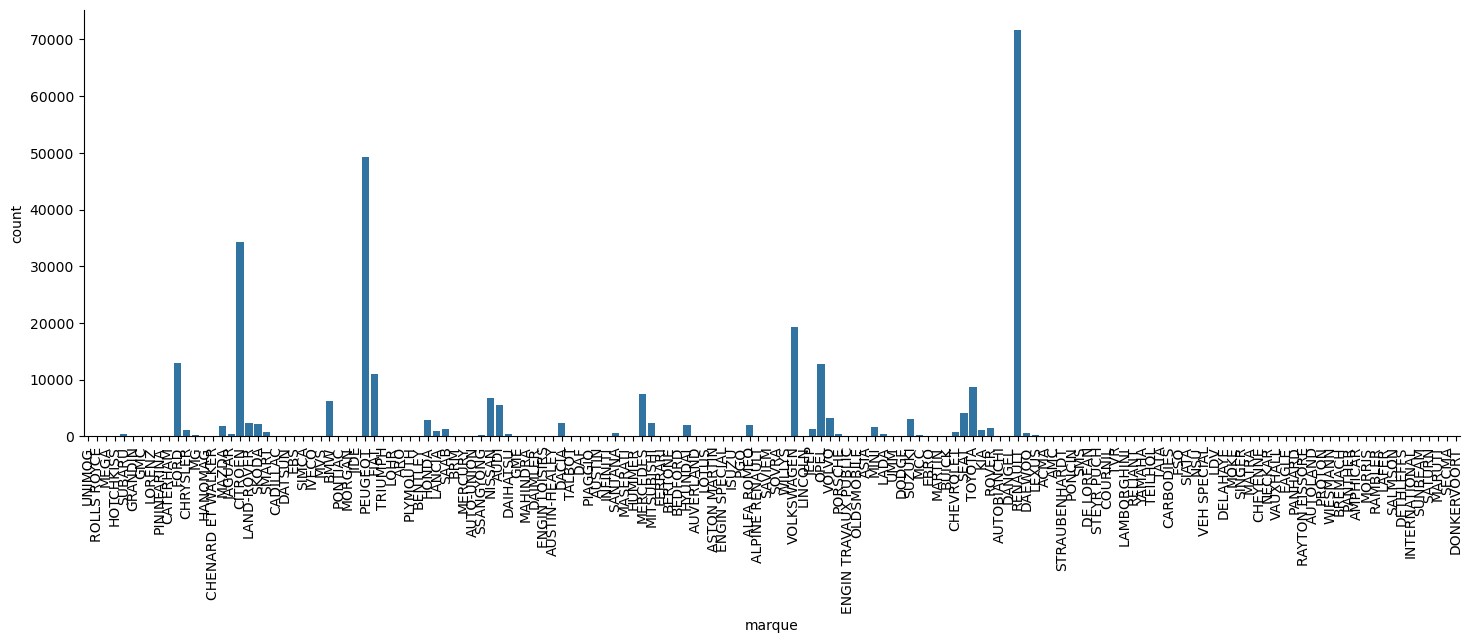

In [29]:
plot_cat("marque")

## code postal, cardinalité, très elevée, par la peine de faire un groupby ça plantera le système

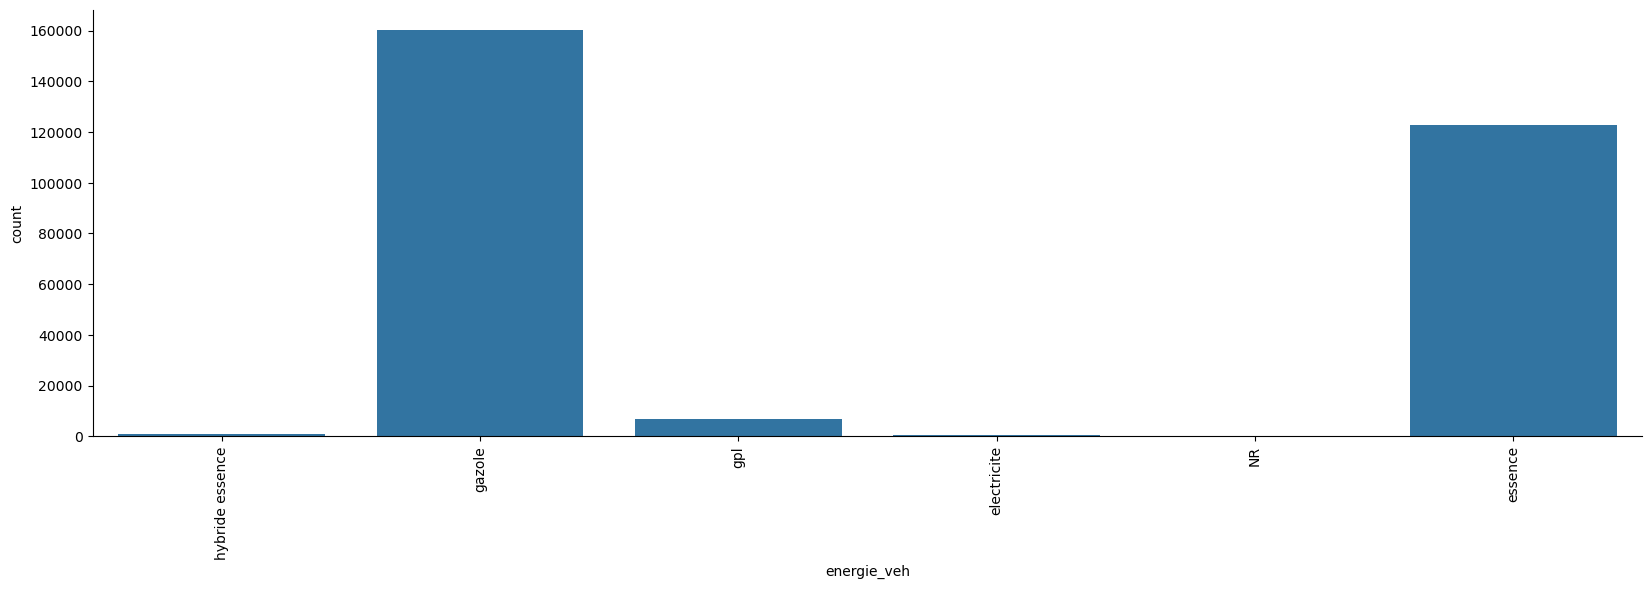

In [30]:
plot_cat("energie_veh")

**Question** Quelles sont vos conclusions ?

**Réponse** Marque et codepostal ont une cardinalité élevée. Grand nombre de catégories ont des occurences de 1. energie_veh, contient encore une anomalie, valeur = NR

**Question** Supprimez les lignes contenant des anomalies dans la colonne energie_veh

In [31]:
n_rows_avant = data.count()
data = data.filter(f.col("energie_veh")!="NR")
n_rows = data.count()
print("Nombre d'enregistrements suppimés ",n_rows_avant-n_rows)

Nombre d'enregistrements suppimés  118


**Question** Le fichier dict_marques_auto.csv contient la liste de toutes les marques de véhicules connues. Utilisez le pour identifier des anomalies dans la colonne marque.

In [32]:
path = "/data/dict_marques_auto.csv"  # le chemin accessible au cluster
marques = spark.read\
            .option("inferSchema",True)\
            .option("header",True)\
            .csv(path)

In [33]:
data = data.join(marques,"marque",how="inner")

**Question** Vérifiez avec describe puis sauvegardez les données nettoyées dans un fichier parquet. 

In [34]:
data.describe().show()

+-------+------+------------------+------------------+------------------+------------------+------------------+------------------+---------------+------------------+-----------------+------------------+------------------+----------+
|summary|marque|                id|   annee_naissance|      annee_permis|      puis_fiscale|           anc_veh|        codepostal|    energie_veh|      kmage_annuel|              crm|              var1|     prime_tot_ttc|      pays|
+-------+------+------------------+------------------+------------------+------------------+------------------+------------------+---------------+------------------+-----------------+------------------+------------------+----------+
|  count|291019|            291019|            291019|            291019|            291019|            291019|            291019|         291019|            291019|           291019|            291019|            291019|    291019|
|   mean|  NULL|149930.02097801174|1983.5920747442606|2002.957305193

**Question** Les opérations de nettoyage effectuées, sont-elles industrialisables ? pourquoi ?

**Réponse** Pas tout a fait industrialisable. Un processus de nettoyage industrialisable doit contrôler systématiquement toutes les variables en appliquant des règles pour vérifier les types, les plages de valeurs et identifier les valeurs extrêmes.

In [35]:
spark.sparkContext.master

'spark://spark-master:7077'

In [36]:
data.write.mode("overwrite").parquet("file:///data/_probe_parq2")

In [37]:
spark.stop()